In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
df=pd.read_csv("../data/raw/Bank Customer Churn Prediction.csv")
print(df.shape)
df.head()

(10000, 12)


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [33]:
df.columns

Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn'],
      dtype='object')

In [34]:
df.drop(columns="customer_id",axis=1,inplace=True)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   credit_score      10000 non-null  int64  
 1   country           10000 non-null  object 
 2   gender            10000 non-null  object 
 3   age               10000 non-null  int64  
 4   tenure            10000 non-null  int64  
 5   balance           10000 non-null  float64
 6   products_number   10000 non-null  int64  
 7   credit_card       10000 non-null  int64  
 8   active_member     10000 non-null  int64  
 9   estimated_salary  10000 non-null  float64
 10  churn             10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


In [36]:
df.duplicated().sum()

0

In [37]:
df.describe()

,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [38]:
df.describe(include="object")

,country,gender
count,10000,10000
unique,3,2
top,France,Male
freq,5014,5457


In [39]:
df.head()

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [40]:
df.nunique()

credit_score         460
country                3
gender                 2
age                   70
tenure                11
balance             6382
products_number        4
credit_card            2
active_member          2
estimated_salary    9999
churn                  2
dtype: int64

In [41]:
to_obj=["tenure","products_number","credit_card","active_member","churn"]
for columns in to_obj:
    df[columns]=df[columns].astype("object")

In [42]:
num_cols=df.select_dtypes(include=["int64","float64"]).columns
cat_cols=df.select_dtypes(include=["object"]).columns
print(f"Numerical Columns: {num_cols}\nCategorical Columns: {cat_cols}")

Numerical Columns: Index(['credit_score', 'age', 'balance', 'estimated_salary'], dtype='object')
Categorical Columns: Index(['country', 'gender', 'tenure', 'products_number', 'credit_card',
       'active_member', 'churn'],
      dtype='object')


## Univariate analysis

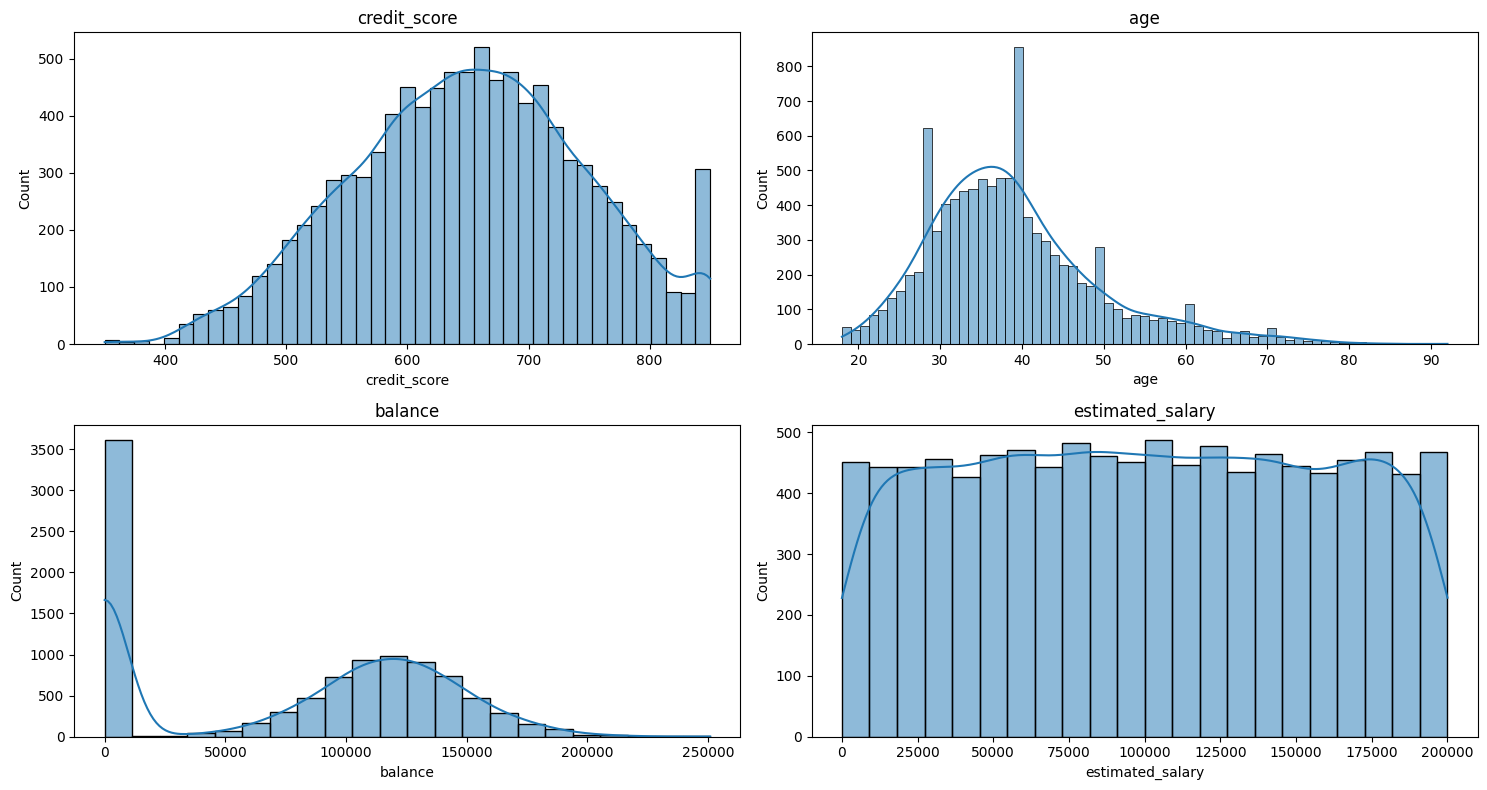

In [43]:
fig,axes=plt.subplots(2,2,figsize=(15,8))

for ax,col in zip(axes.flat,num_cols):
    sns.histplot(df[col],kde=True,ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

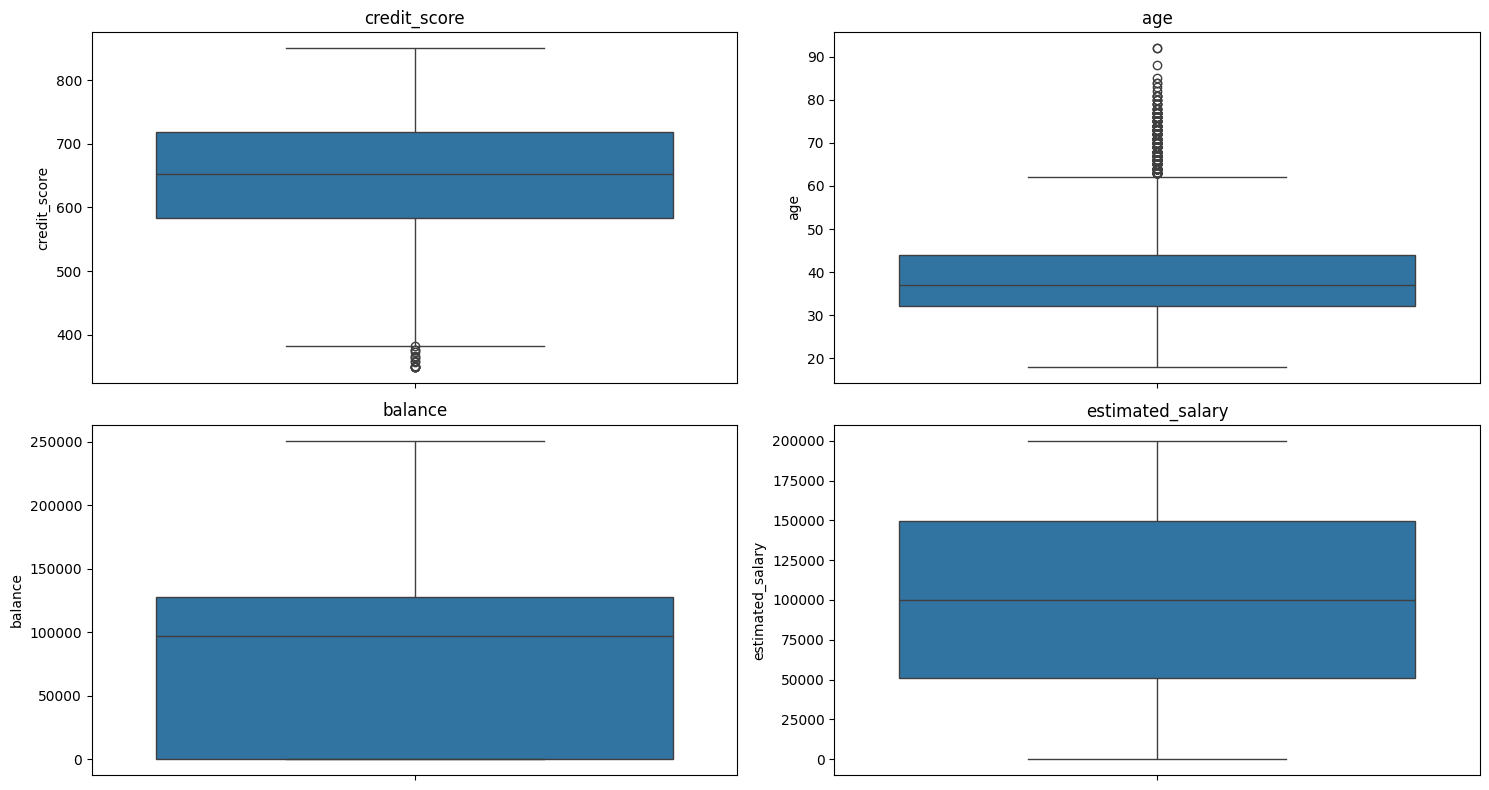

In [44]:
fig,axes=plt.subplots(2,2,figsize=(15,8))

for ax,col in zip(axes.flat,num_cols):
    sns.boxplot(df[col],ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [45]:
for cols in cat_cols:
    print(df[cols].nunique())

3
2
11
4
2
2
2


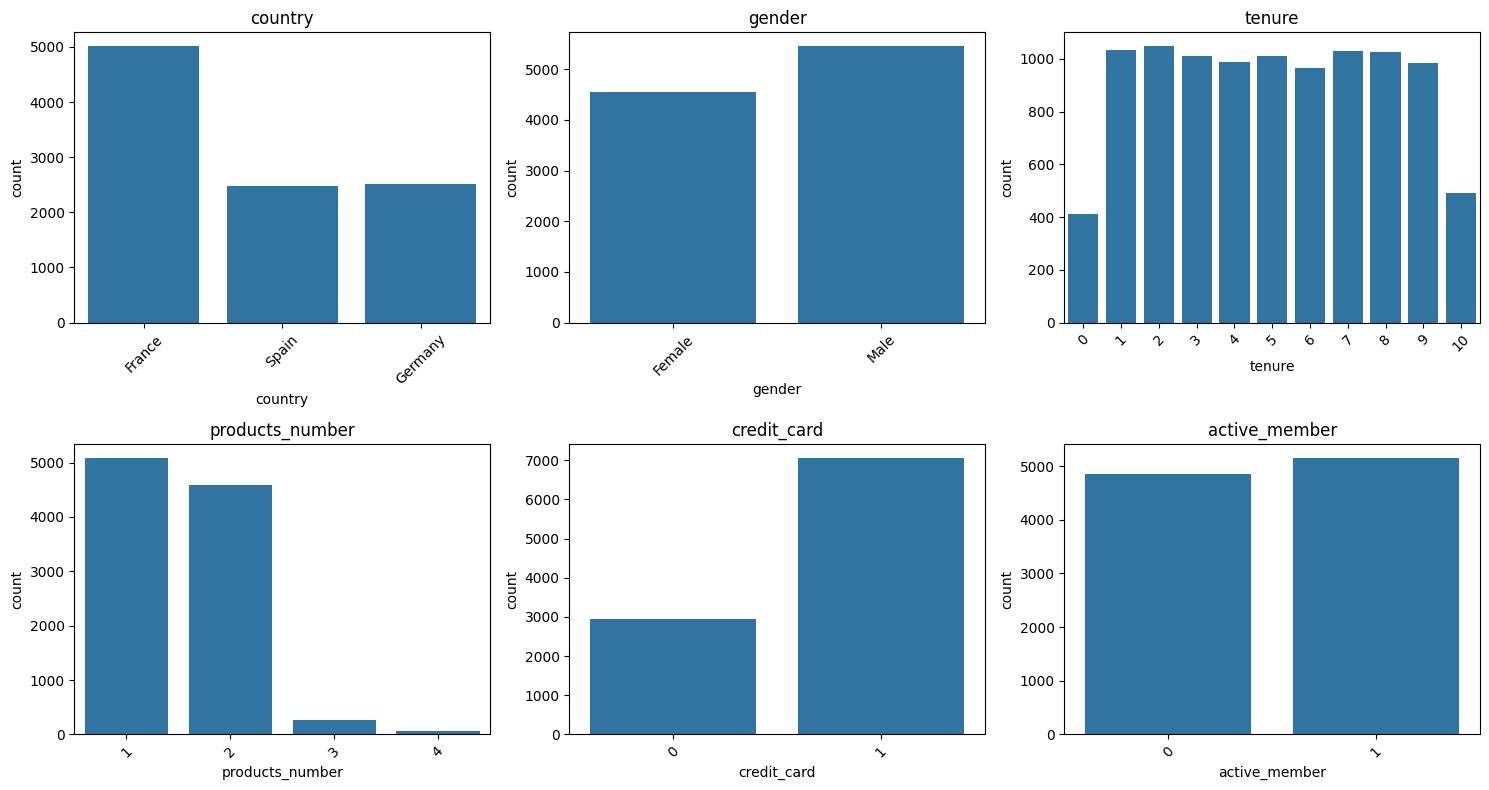

In [46]:
fig,axes=plt.subplots(2,3,figsize=(15,8))

for ax,col in zip(axes.flat,cat_cols):
    sns.countplot(x=df[col],ax=ax)
    ax.set_title(f'{col}')
    ax.tick_params(axis='x',rotation=45)

plt.tight_layout()
plt.show()

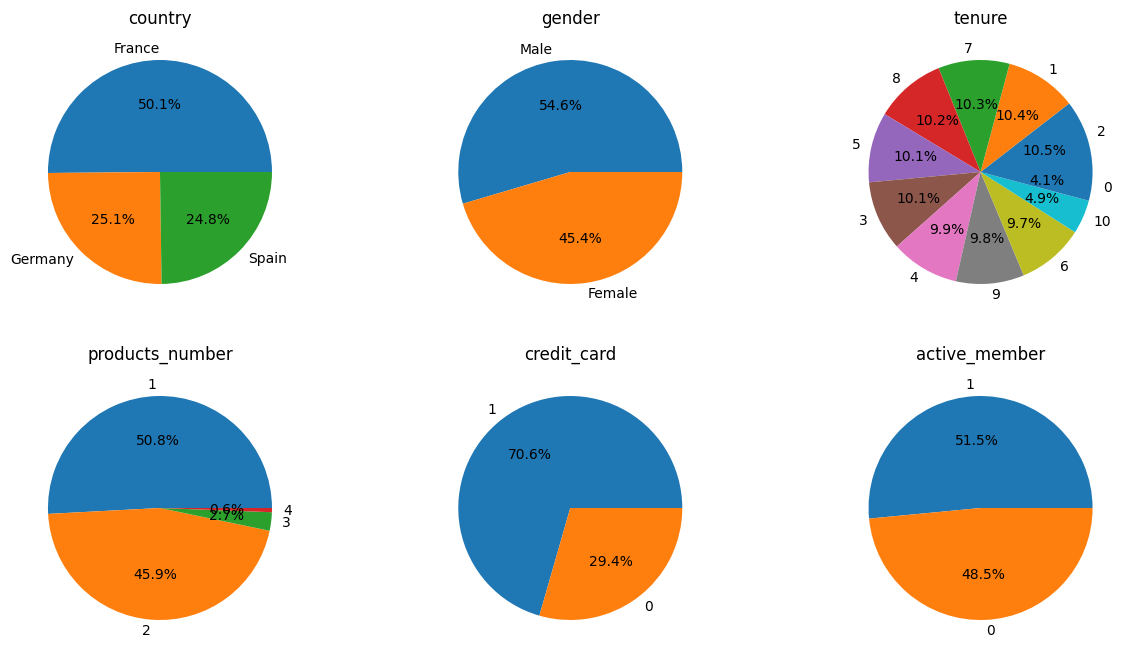

In [47]:
pie_cols=["country","gender","tenure","products_number","credit_card","active_member"]

fig,axes=plt.subplots(2,3,figsize=(15,8))

for ax,col in zip(axes.flat,pie_cols):
    
    df[col].value_counts().plot(kind='pie',autopct='%1.1f%%',ax=ax)
    ax.set_title(f'{col}')
    ax.set_ylabel('')

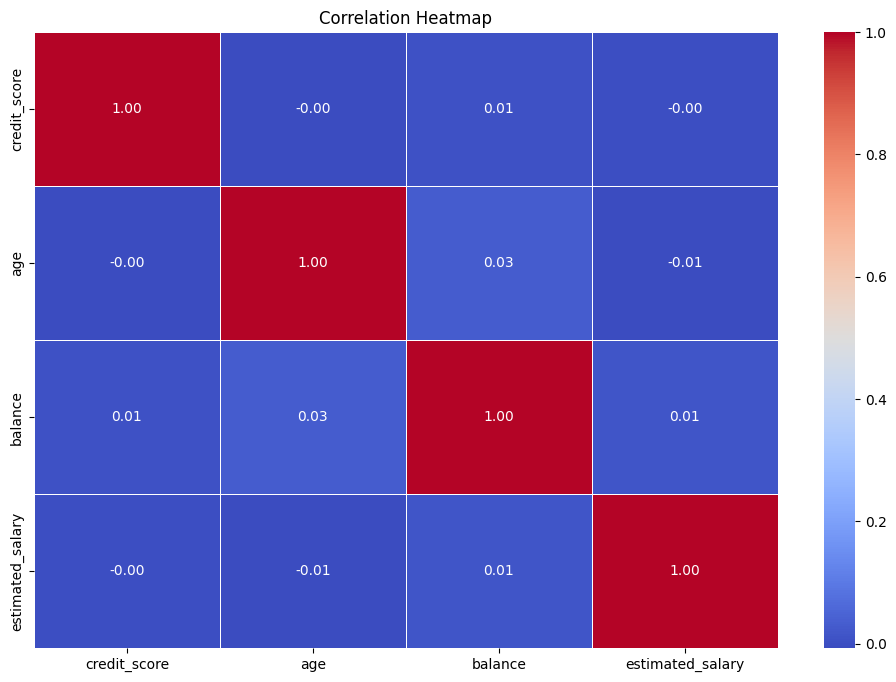

In [48]:
corr_matrix=df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix,annot=True,fmt='.2f',cmap='coolwarm',linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [49]:
# ohe_columns=["tenure","products_number","credit_card","active_member","churn"]

eda_df=df.copy()
eda_df=pd.get_dummies(eda_df,columns=["country","gender"])
eda_df.head().T

,0,1,2,3,4
credit_score,619,608,502,699,850
age,42,41,42,39,43
tenure,2,1,8,1,2
balance,0.0,83807.86,159660.8,0.0,125510.82
products_number,1,1,3,2,1
credit_card,1,0,1,0,1
active_member,1,1,0,0,1
estimated_salary,101348.88,112542.58,113931.57,93826.63,79084.1
churn,1,0,1,0,0
country_France,True,False,True,True,False


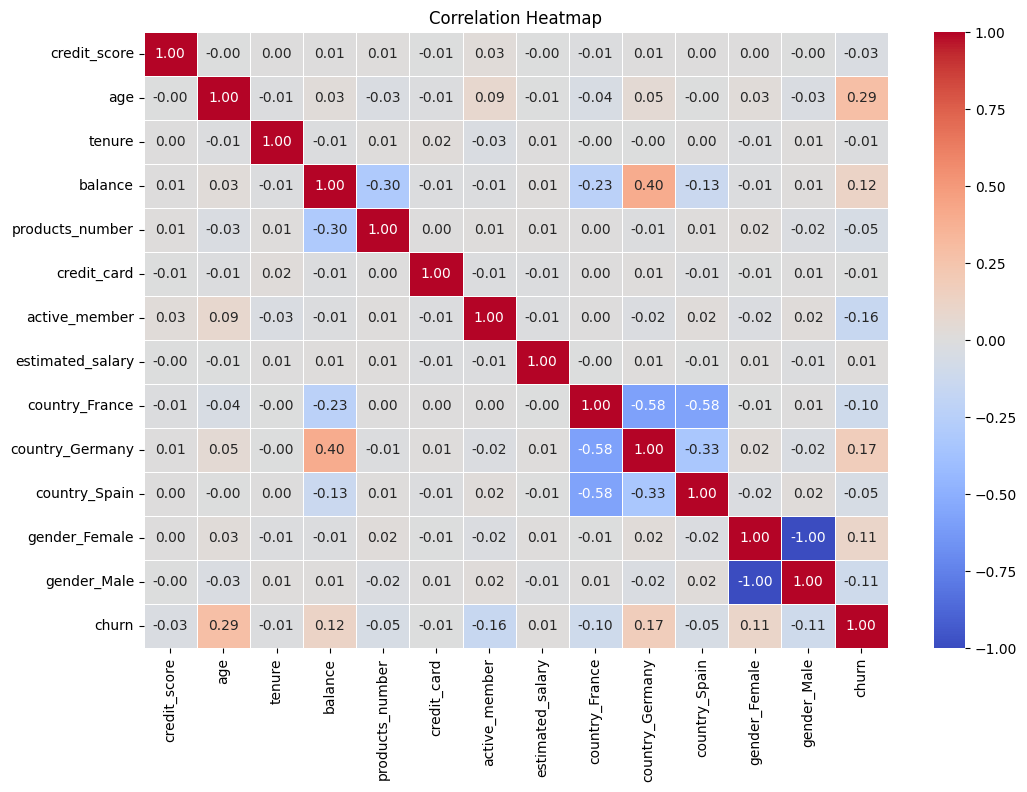

In [50]:
mat_cols = [col for col in eda_df.columns if col != 'churn'] + ['churn']
corr_matrix=eda_df[mat_cols].corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix,annot=True,fmt='.2f',cmap='coolwarm',linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

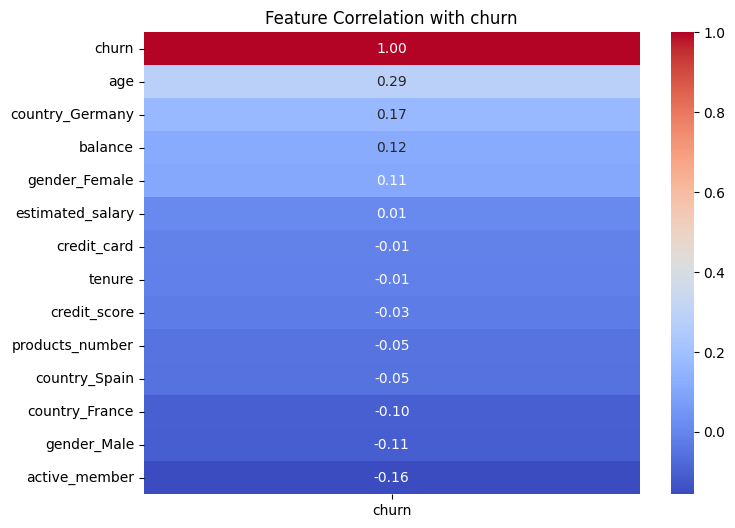

In [51]:
corr_churn=(eda_df.corr()['churn'].sort_values(ascending=False))
plt.figure(figsize=(8,6))
sns.heatmap(corr_churn.to_frame(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Feature Correlation with churn')
plt.show()

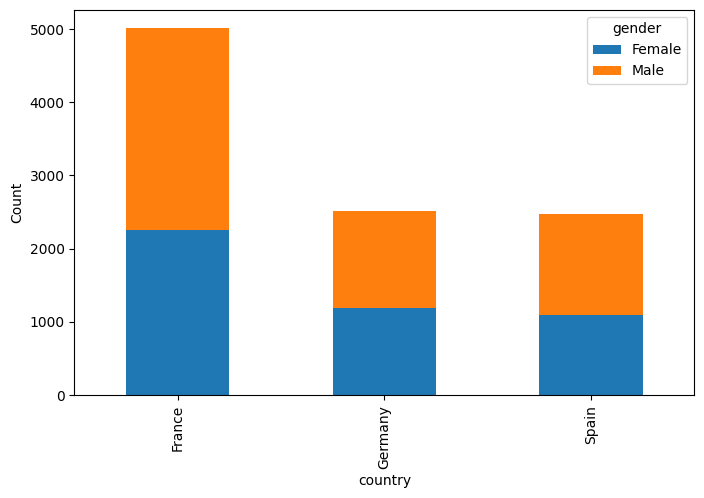

In [52]:
cross_tab = pd.crosstab(
    df['country'],
    df['gender']
)

cross_tab.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.ylabel('Count')

plt.show()

In [53]:
# Churn rate by single features
segments = ["gender", "country", "active_member", "products_number", "credit_card"]

churn_numeric = df["churn"].astype(int)

for col in segments:
    rate = churn_numeric.groupby(df[col]).agg(["mean", "count"]).rename(columns={"mean": "churn_rate"})
    rate["churn_rate"] = (rate["churn_rate"].astype(float) * 100).round(2)
    print(f"\nChurn rate by {col}:")
    print(rate)


Churn rate by gender:
        churn_rate  count
gender                   
Female       25.07   4543
Male         16.46   5457

Churn rate by country:
         churn_rate  count
country                   
France        16.15   5014
Germany       32.44   2509
Spain         16.67   2477

Churn rate by active_member:
               churn_rate  count
active_member                   
0                   26.85   4849
1                   14.27   5151

Churn rate by products_number:
                 churn_rate  count
products_number                   
1                     27.71   5084
2                      7.58   4590
3                     82.71    266
4                    100.00     60

Churn rate by credit_card:
             churn_rate  count
credit_card                   
0                 20.81   2945
1                 20.18   7055


In [54]:
# Age bins
df["age_bin"] = pd.cut(df["age"], bins=[18, 30, 40, 50, 60, 92])
age_rate = churn_numeric.groupby(df["age_bin"]).agg(["mean", "count"]).rename(columns={"mean": "churn_rate"})
age_rate["churn_rate"] = (age_rate["churn_rate"].astype(float) * 100).round(2)
print("Churn rate by age bin:")
print(age_rate)

Churn rate by age bin:
          churn_rate  count
age_bin                    
(18, 30]        7.50   1946
(30, 40]       12.09   4451
(40, 50]       33.97   2320
(50, 60]       56.21    797
(60, 92]       24.78    464


C:\Users\shubh\AppData\Local\Temp\ipykernel_14636\1444087183.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_rate = churn_numeric.groupby(df["age_bin"]).agg(["mean", "count"]).rename(columns={"mean": "churn_rate"})


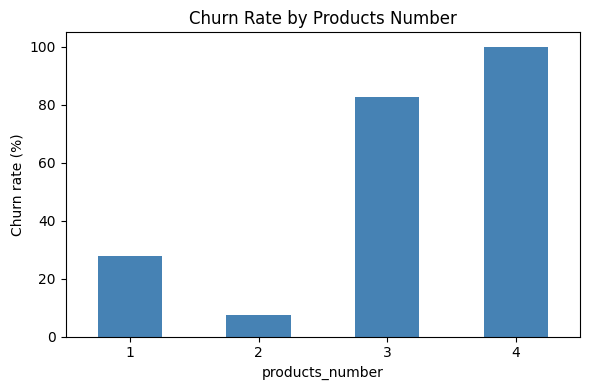

In [55]:
# products_number churn rate bar chart
prod_rate = churn_numeric.groupby(df["products_number"]).mean().astype(float) * 100
plt.figure(figsize=(6, 4))
prod_rate.plot(kind="bar", color="steelblue")
plt.ylabel("Churn rate (%)")
plt.title("Churn Rate by Products Number")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [56]:
# country x active_member interaction table
interaction = churn_numeric.groupby([df["country"], df["active_member"]]).agg(["mean", "count"]).rename(columns={"mean": "churn_rate"})
interaction["churn_rate"] = (interaction["churn_rate"].astype(float) * 100).round(2)
print("\nChurn rate by country x active_member:")
print(interaction)


Churn rate by country x active_member:
                       churn_rate  count
country active_member                   
France  0                   21.13   2423
        1                   11.50   2591
Germany 0                   41.08   1261
        1                   23.72   1248
Spain   0                   23.35   1165
        1                   10.75   1312


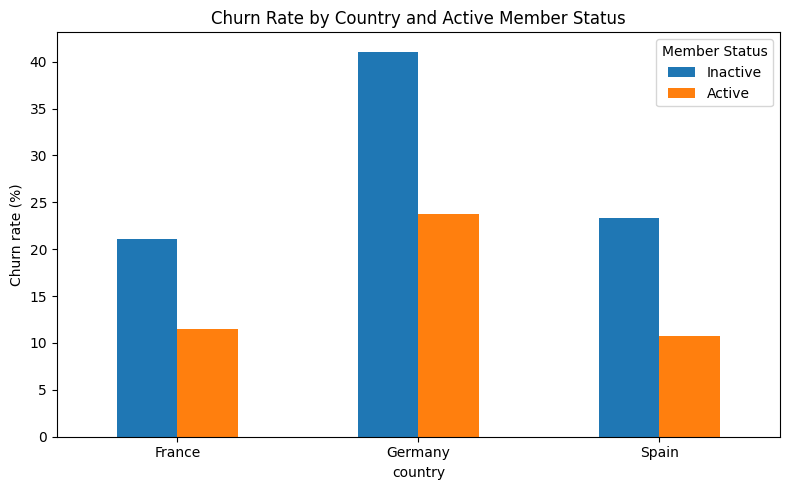

In [57]:
# country x active_member bar chart
pivot = pd.pivot_table(pd.DataFrame({"country": df["country"], "active_member": df["active_member"], "churn": churn_numeric}),
                        index="country", columns="active_member", values="churn", aggfunc="mean") * 100
pivot.columns = ["Inactive", "Active"]
pivot.plot(kind="bar", figsize=(8, 5))
plt.ylabel("Churn rate (%)")
plt.title("Churn Rate by Country and Active Member Status")
plt.xticks(rotation=0)
plt.legend(title="Member Status")
plt.tight_layout()
plt.show()

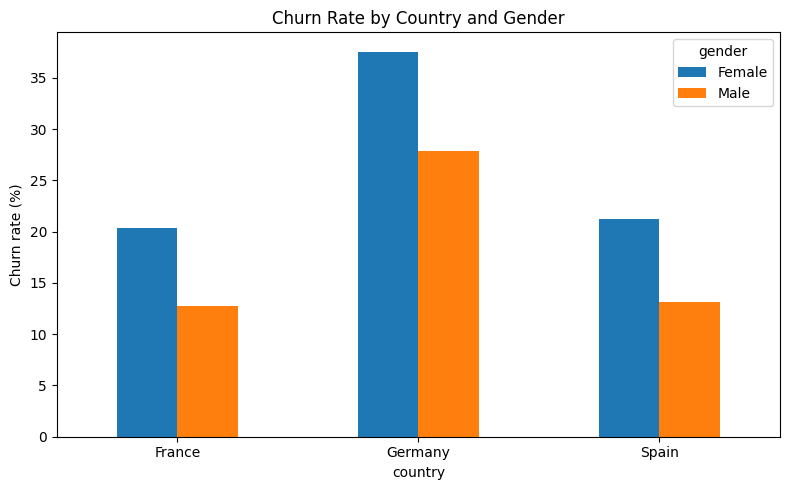

In [58]:
# gender x country interaction
gc_pivot = pd.pivot_table(pd.DataFrame({"country": df["country"], "gender": df["gender"], "churn": churn_numeric}),
                           index="country", columns="gender", values="churn", aggfunc="mean") * 100
gc_pivot.plot(kind="bar", figsize=(8, 5))
plt.ylabel("Churn rate (%)")
plt.title("Churn Rate by Country and Gender")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Inferences 

**Dataset overview**
- 10,000 customers, 11 features after dropping `customer_id`, no missing values or duplicates.
- Overall churn rate: **20.37%** — moderately imbalanced target.

**Strongest churn drivers**
- **Products number** is the single biggest driver, and it's non-linear: 1 product → 27.71% churn, 2 products → 7.58% (lowest), but **3 products → 82.71%** and **4 products → 100%** churn. Customers with 3+ products are almost guaranteed to leave.
- **Country**: Germany churns at **32.44%**, roughly 2x France (16.15%) and Spain (16.67%).
- **Active membership**: inactive members churn at **26.85%** vs. **14.27%** for active members.
- **Age**: churn rises steadily with age and peaks in the 50–60 bracket (**56.21%**), then drops for 60+ (24.78%) — not a simple linear trend, so the 0.29 Pearson correlation understates the mid-life risk spike.
- **Gender**: females churn more (**25.07%**) than males (**16.46%**).

**Interaction effects**
- Country and activity status compound: **inactive customers in Germany churn at 41.08%**, the highest-risk segment in the data, while even *active* German customers (23.72%) still churn more than *inactive* French or Spanish customers.
- This suggests geography isn't just a standalone effect — it interacts with engagement.

**Weak / non-drivers**
- `credit_card` ownership shows almost no difference (20.81% vs 20.18% churn) — not predictive.
- `credit_score`, `tenure`, and `estimated_salary` all had near-zero correlation with churn in the heatmap and don't show meaningful separation.

**Distribution notes**
- `balance` is bimodal — a large spike at 0 plus a roughly normal cluster around 100–150k.
- `estimated_salary` is essentially uniform, hinting at simulated/synthetic data rather than organic salaries.
- `age` and `credit_score` are right-/slightly left-skewed with some outliers, but nothing extreme enough to require heavy treatment.

**Methodological note**
- The linear correlation matrix (heatmap) *underestimated* the impact of `products_number` and `age` because their relationships with churn are non-linear/threshold-based — the groupby churn-rate tables surfaced patterns the correlation matrix missed. Any modeling step should account for this (e.g., binning age, treating products_number as categorical, or using tree-based models that capture non-linearities natively).